# 📈 The Figure Data Structure in Python

---
## 📘 01 — The Figure Data Structure 
## 🧠 Core Idea

* A Plotly figure is just a structured object.

## 1. 📘 Overview

* Plotly’s Python package is used to create and manage visualizations like charts and maps using figure objects. These figures can be defined as dictionaries or `plotly.graph_objects.Figure` objects and are converted into JSON, which is then rendered using the Plotly.js library behind the scenes—without requiring direct interaction with JavaScript.



### What We'll Cover
1. **Overview** — import required libraries, set up environment, and configure plotting defaults
2. **Accessing figure structures in Dash** — understand how Plotly figures are structured and accessed inside Dash apps
3. **Figures as Trees of Attributes** — explore how figures are organized as nested attribute trees
4. **The Top-Level data Attribute** — learn how traces store and represent the actual plotted data
5. **The Top-Level layout Attribute** — customize layout elements like titles, axes, legends, and styling
6. **Feature Engineering** — transform and create meaningful features before visualization
7. **The config Object** — control interactivity features like zoom, toolbar, and responsiveness
8. **Positioning With Paper, Container Coordinates, or Axis Domain Coordinates** — precisely place annotations, shapes, and elements
9. **2D Cartesian Trace Types and Subplots** — work with line, bar, scatter plots and multi-plot layouts
 10. **3D, Polar, Ternary and Smith Trace Types and Subplots** — visualize complex multi-dimensional data
 11. **Map Trace Types and Subplots** — create geographic and map-based visualizations
 12. **Traces Which Are Their Own Subplots** — understand special trace types like pie, sunburst, etc.
 13. **Carpet Trace Types and Subplots** — work with advanced coordinate systems and contour-style plots
 14. **Trace Types, Legends and Color Bars** — manage visual encoding, legends, and color scales
 15. **What About Dash?** — integrate everything into interactive dashboards for real-world use

---

In [132]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dash import Dash, dcc, html , Input, Output
import numpy as np
# !pip install dash

In [133]:
Figure = {
    'data' : [...],
    'layout' : {...},
    'frames' : [...]
    
}

## 🔥 1. What is a Figure?

In Plotly Python Graphing Library:

A figure = complete chart
It contains:
Data (what to plot)
Layout (how it looks)
Frames (for animation)

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': array(['a', 'b', 'c', 'd'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'BAUHCA==', 'dtype': 'i1'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'sample figure'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})


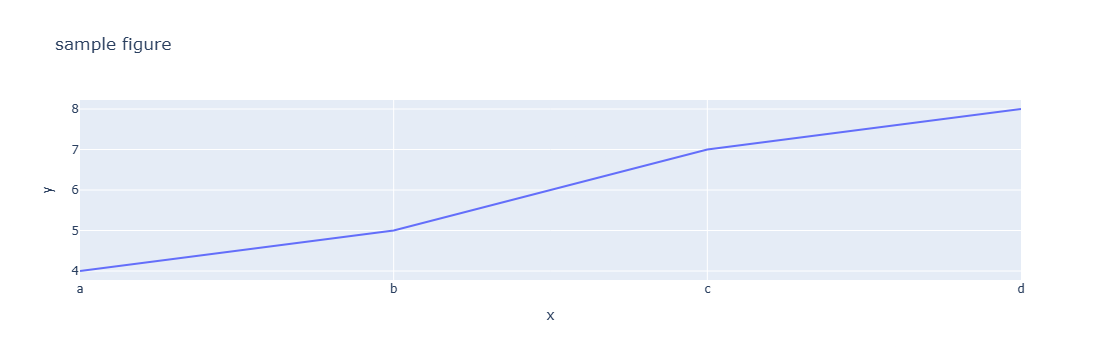

In [134]:
fig = px.line(x = ['a','b','c','d'] , y = [4,5,7,8] ,  title="sample figure")
print(fig)
fig.show()

# 📘 2. Accessing Figure Structures in Dash 
* Dash is used to turn Plotly charts into interactive web applications
* You create a Plotly figure, then pass it into Dash to display in a web app
* Dash handles UI, layout, and interactivity (buttons, sliders, etc.)
* You don’t need JavaScript — everything works in Python

## ⚡ One-Line Understanding

* 👉 Dash = use Plotly figures inside a web app to make interactive dashboards.
* Dash lets you display Plotly figures in interactive web apps using Python.

## 🚀 How Plotly Figure Goes into Dash

In [135]:
px.line (x = [5,3,6,9] , y = [7,8,9,2] )
app = Dash()

app.layout = html.Div([ # app layout using html.div
    dcc.Graph(figure =fig)
])
app.run(debug = True ) #  port=8051 

In [179]:
import json

fig = px.line(
    x=["a","b","c"], y=[1,3,2], # replace with your own data source
    title="sample figure", height=325
)

app = Dash(__name__)

app.layout = html.Div([
    html.H4('Displaying figure structure as JSON'),
    dcc.Graph(id="graph", figure=fig),
    dcc.Clipboard(target_id="structure"),
    html.Pre(
        id='structure',
        style={
            'border': 'thin lightgrey solid',
            'overflowY': 'scroll',
            'height': '275px'
        }
    ),
])


@app.callback(
    Output("structure", "children"),
    Input("graph", "figure"))
def display_structure(fig_json):
    return json.dumps(fig_json, indent=2)


app.run(debug=True)

# 📓3. Figures as Trees of Attributes

## 🌳 Core Idea
* A Plotly figure is like a tree structure (nested dictionary) where everything is organized into attributes.

## 🧩 3 Main Parts (Root Level)

 > Every figure has 3 top-level branches:
1. data → actual plots (traces like scatter, bar, etc.)
2.  layout → styling (title, axes, colors, fonts)
3.  frames → used for animations
4.  🔗 Attribute Paths


 > Each property is accessed using a path:
1. layout.width → width of chart
2. layout.title.text → title text
3.  data[0].name → name of first trace

In [137]:
show = fig.layout.title.text = 'My Chart'
show

'My Chart'

## ⚡ Final One-Liner

* Plotly figures are nested attribute trees, where data, layout, and frames control everything—and you modify them using structured paths or update methods.

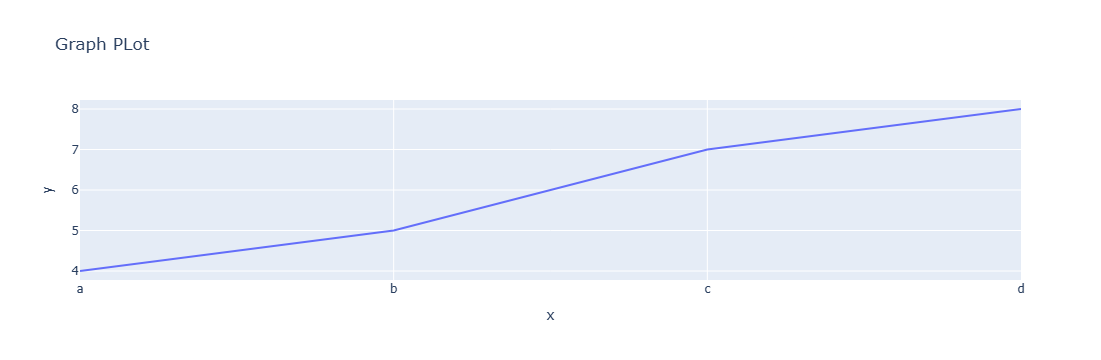

In [138]:
fig.update_layout(title_text = 'Graph PLot')

# 🗒️ 4. The Top-Level data Attribute

## ⚡ Core Idea

1.  In Plotly, every figure is built using:
2.  data = what to draw (the actual visuals)

## 🧠 What is data?
1. data is a list of traces
2. A trace = one visual layer in your chart

> 👉 Think like:

1. 1 trace = 1 graph (line, bar, pie, etc.)
2. Multiple traces = multiple elements in one figure

In [139]:
fig_dict = {
    'data' : [ # adding multiple traces
        {'type' : 'scatter' , 'x' : [2,3,4,5,6] , 'y' : [5,7,8,4,3]}, # list of traces 
        {'type' : 'bar' , "x": [1,2,3], "y": [2,3,1]} # a one visual layer of a chart
    ]
}

In [140]:
# fig = go.Figure()

# fig.add_trace(go.Scatter(x=[2,3,4,5,6], y=[5,7,8,4,3]))
# fig.add_trace(go.Bar(x=[1,2,3], y=[2,3,1]))

## ♻️ Reuse the data from your first

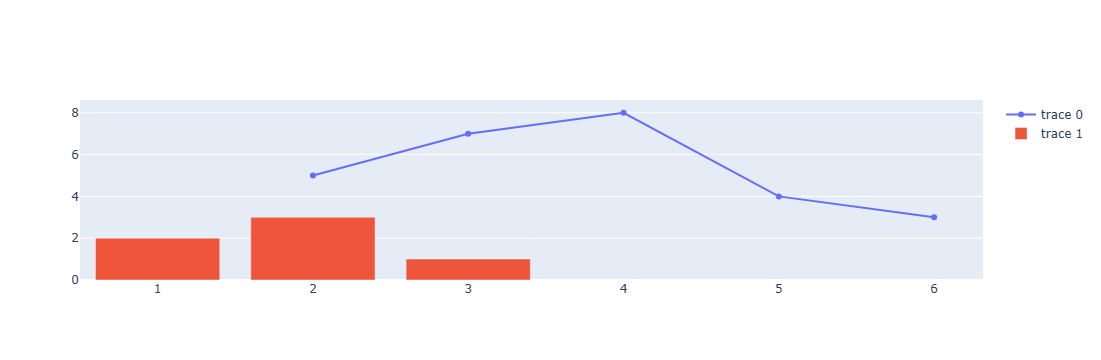

In [141]:
fig2 = go.Figure(fig_dict)
fig2.show()

## 🧠 If i Want to add_trace() (Dynamic Way)

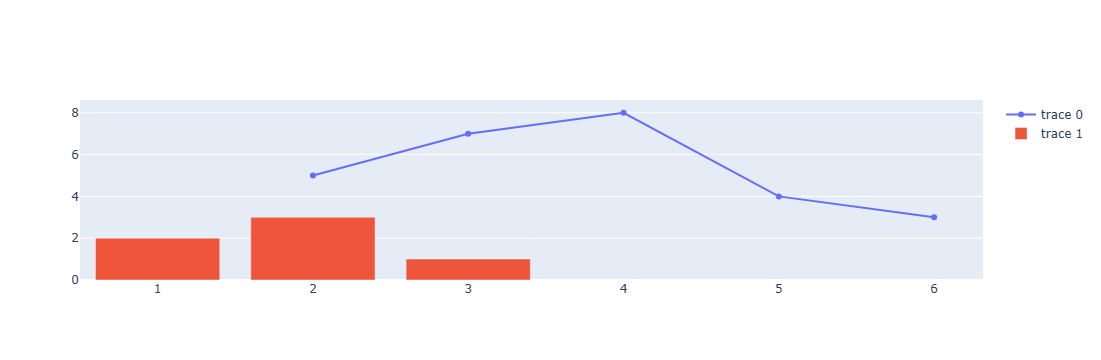

In [142]:
fig = go.Figure()
for trace in fig_dict['data']:
    fig.add_trace(trace)
fig.show()

In [143]:
# fig = go.Figure()
# for trace in fig_dict['data']:
#     if trace['type'] == 'scatter':
#         show3 += fig.add_trace(go.Scatter(**trace))
#     elif trace['type'] == 'bar':
#         show3 += fig.add_trace(go.Bar(**trace))
# fig.show()

## 🚀 Key Insight (Very Important)

👉 In Plotly:

1. data dict format = raw structure
2. go.Figure() = renderer
3. add_trace() = manual building
---

## 🔷 5.  Top-Level layout Attribute (Clean Understanding)

>  layout = controls everything that is NOT data

* It’s a dictionary that defines:

1. structure
2. styling
3. positioning
4. interactivity

In [144]:
layout = {
    "structure": ...,   # size, margins
    "style": ...,       # colors, fonts
    "axes": ...,        # xaxis, yaxis
    "extras": ...,      # annotations, shapes
    "controls": ...     # buttons, sliders
}

## 🚀 Complete Plotly Figure (All-in-One)

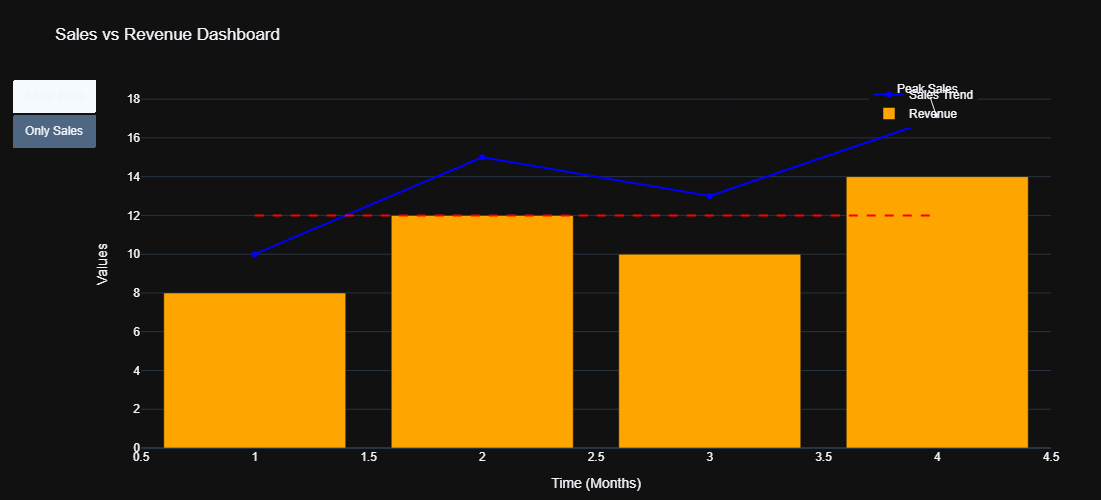

In [145]:
# Create figure
fig = go.Figure(

    # 🔹 DATA → WHAT to draw
    data=[
        go.Scatter(
            x=[1, 2, 3, 4],
            y=[10, 15, 13, 17],
            mode='lines+markers',
            name='Sales Trend',  # legend entry
            line=dict(color='blue')
        ),

        go.Bar(
            x=[1, 2, 3, 4],
            y=[8, 12, 10, 14],
            name='Revenue',
            marker=dict(color='orange')
        )
    ],

    # 🔹 LAYOUT → HOW it looks
    layout=dict(

        # Figure size & spacing (paper area)
        width=800,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50),

        # 🎨 Global styling
        template='plotly_dark',
        font=dict(family="Arial", size=12),

        #  Title
        title="Sales vs Revenue Dashboard",

        # 📊 Axes (Cartesian subplot)
        xaxis=dict(title="Time (Months)"),
        yaxis=dict(title="Values"),

        #  Legend position (paper coordinates: 0 → 1)
        legend=dict(x=0.8, y=1),

        # ✏️ Annotation (extra info on chart)
        annotations=[
            dict(
                text="Peak Sales",
                x=4,
                y=17,
                showarrow=True,
                arrowhead=2
            )
        ],

        # 📐 Shapes (highlight region/line)
        shapes=[
            dict(
                type="line",
                x0=1,
                x1=4,
                y0=12,
                y1=12,
                line=dict(color="red", dash="dash")
            )
        ],

        # 🎛 Interactive button (basic example)
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Show Both",
                        method="update",
                        args=[{"visible": [True, True]}]
                    ),
                    dict(
                        label="Only Sales",
                        method="update",
                        args=[{"visible": [True, False]}]
                    )
                ]
            )
        ]
    )
)

# Show figure
fig.show()

# 📦 6. The Top-Level frames Attribute

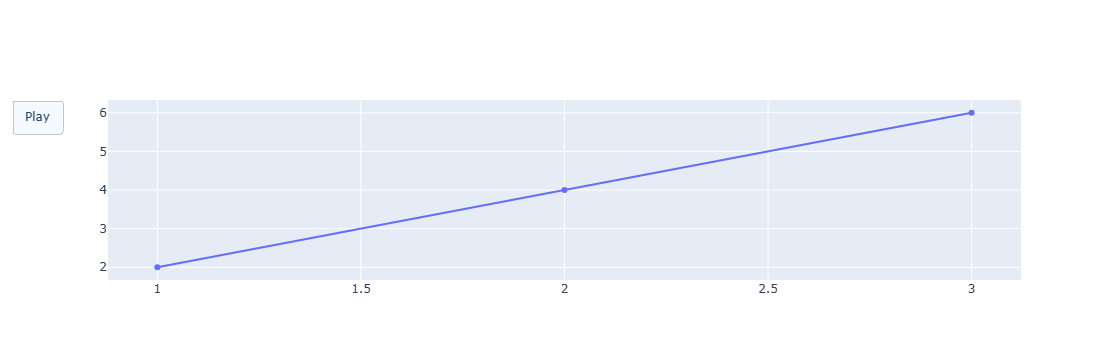

In [146]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Scatter(x=[1,2,3], y=[2,4,6])],  # initial state
    layout=go.Layout(
        updatemenus=[{ # layout.updatemenus ->  controls animation
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None]
                }
            ]
        }]
    ),
    frames=[ #  -> creates animation
        go.Frame(data=[go.Scatter(x=[1,2,3], y=[3,6,9])]),
        go.Frame(data=[go.Scatter(x=[1,2,3], y=[4,8,12])])
    ]
)

fig.show()

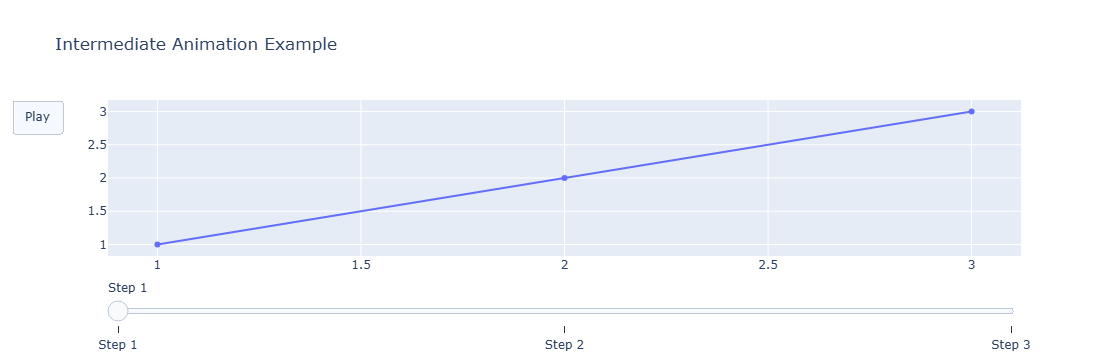

In [147]:
# 1. Define Frames (Animation Steps)

frames = [
    go.Frame(
        data=[go.Scatter(x=[1, 2, 3], y=[1, 2, 3], mode="lines+markers")],
        name="Step 1"
    ),
    go.Frame(
        data=[go.Scatter(x=[1, 2, 3], y=[2, 4, 6], mode="lines+markers")],
        name="Step 2"
    ),
    go.Frame(
        data=[go.Scatter(x=[1, 2, 3], y=[3, 6, 9], mode="lines+markers")],
        name="Step 3"
    )
]


# 2. Create Figure

fig = go.Figure(
    
    # Initial Data (First Frame)
    data=[
        go.Scatter(
            x=[1, 2, 3],
            y=[1, 2, 3],
            mode="lines+markers"
        )
    ],

    
    # 3. Layout (Controls + Styling)
    
    layout=go.Layout(
        title="Intermediate Animation Example",

        # 🎮 Play Button
        updatemenus=[ # ->  controls animation
            {
                "type": "buttons",
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 500, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 300}
                            }
                        ]
                    }
                ]
            }
        ],

        # 🎚️ Slider Control
        sliders=[
            {
                "active": 0,
                "steps": [
                    {
                        "label": frame.name,
                        "method": "animate",
                        "args": [
                            [frame.name],
                            {
                                "frame": {"duration": 500, "redraw": True},
                                "mode": "immediate",
                                "transition": {"duration": 300}
                            }
                        ]
                    }
                    for frame in frames
                ]
            }
        ]
    ),

    
    # 4. Attach Frames
    
    frames=frames
)

fig.show()

## 🧠 What This Combined Version Fixes
1. ✅ Clean separation: frames / data / layout
2. ✅ Working Play button
3. ✅ Fully functional slider
4. ✅ Smooth animation (frame + transition)
5. ✅ redraw=True → prevents glitches
   
##  ⚡ Final Mental Model (Now You’re Intermediate)

> 👉 You didn’t just “combine code” — you built a complete animation system:

1. data → starting state
2. frames → all future states
3. layout → controls (play + slider)
---

# 🧠 7. What is the config object?

1. data → what to plot
2. layout → how it looks
3. config → how users interact with it at runtime

## 🎯 What config Controls

> Think of it as UI/UX settings for the chart:

1. 🧰 Modebar (toolbar at top-right)
* Show / hide buttons
* Add custom tools
* Remove unwanted tools
  
2. 🖱️ Mouse behavior
* Zoom
* Scroll zoom
* Pan behavior
  
3. 📸 Export settings
* Download image button
* File format (PNG, SVG, etc.)

## 🔥 Common Config Options

In [148]:
config = {
    'displayModeBar' : True ,
    'scrollZoom' : True,
    'displaylogo' : False,
    'modeBarButtonToRemove' : ['Zoom' , 'Pan'],
    "toImageButtonOptions": {
        "format": "png",
        "filename": "my_plot",
        "height": 600,
        "width": 800,
        "scale": 2
    }
}

## 🧪 Combined Example (Data + Layout + Config)

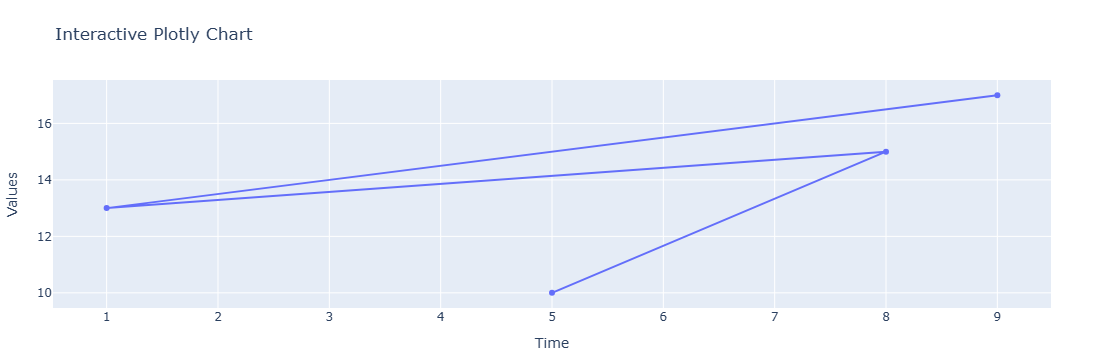

In [149]:
fig = go.Figure()
# 1. -> data
fig.add_trace(go.Scatter(
    x=[5, 8, 1, 9],
    y=[10, 15, 13, 17],
    mode='lines+markers',
    name='Sales Trend'
))
# 2. -> Layout
fig.update_layout(
    title = "Interactive Plotly Chart",
    xaxis_title = 'Time',
    yaxis_title = 'Values',
    margin=dict(l=50, r=50, t=80, b=50)
) 

# 3. -> 
config = {
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["lasso2d"],
    "toImageButtonOptions": {
        "format": "png",
        "filename": "custom_chart",
        "scale": 2
    }
}

fig.show(config = config)

# 🎯 8. Positioning in Plotly (3 Coordinate Systems)
* Plotly lets you place elements (annotations, shapes, legends, titles) using three different coordinate systems:

# 1️⃣ Paper Coordinates (Most Important)

>  Relative to the plot area (excluding margins)

1. (0,0) → bottom-left of plotting area
2. (1,1) → top-right of plotting area

>📌 Not pixels — fractions
🔹 Example

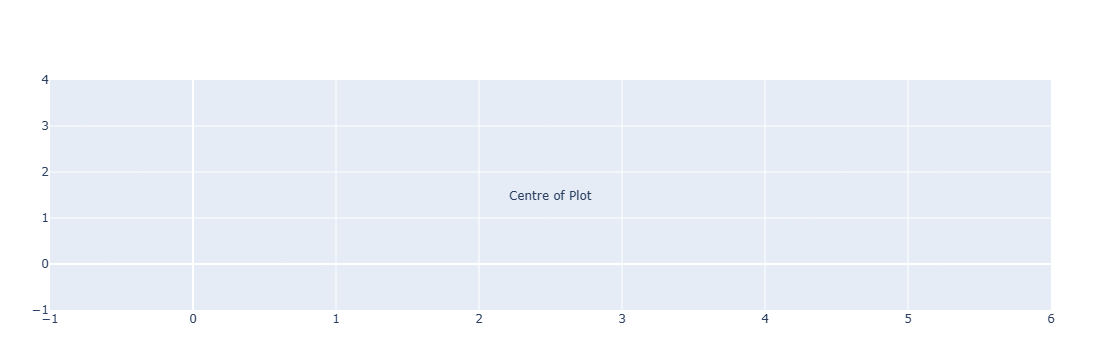

In [150]:
fig = go.Figure()

fig.add_annotation(
    text = 'Centre of Plot',
    x = 0.5,
    y = 0.5,
    xref= 'paper',
    yref= 'paper',
    showarrow= False
)
fig.update_layout(
    margin=dict(l=50, r=50, t=80, b=50)
)
fig.show()

## 2️⃣ Container Coordinates (Full Figure)

>  Relative to entire figure (including margins)

1. (0,0) → bottom-left of full figure
2. (1,1) → top-right of full figure

>📌 Used mainly for titles

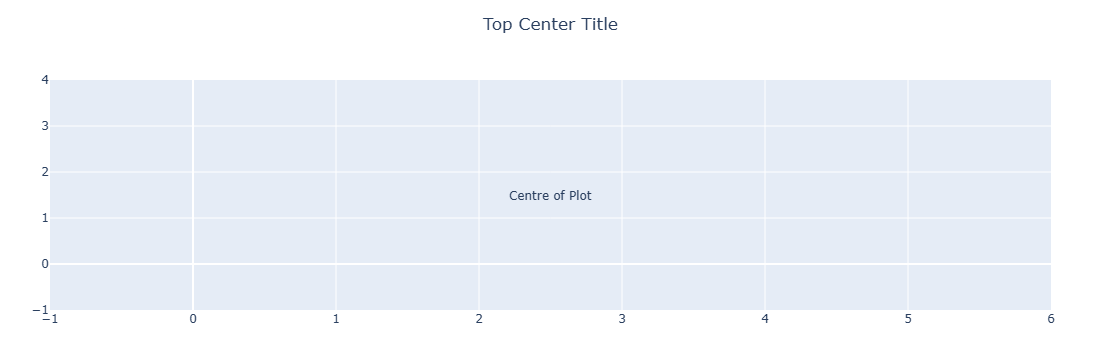

In [151]:
fig.update_layout(
    title=dict(
        text="Top Center Title",
        x=0.5,
        y=0.95,   # near top of full figure
        xanchor="center"
    )
)

## 3️⃣ Axis Domain Coordinates (Advanced & Powerful)

>  Relative to a specific axis range area

1. (0,0) → start of axis
2. (1,1) → end of axis

> 📌 Works great with subplots

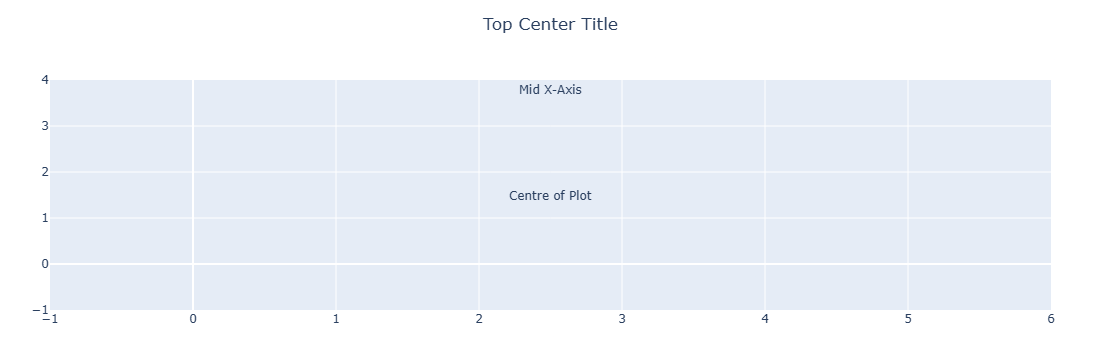

In [152]:
fig.add_annotation(
    text="Mid X-Axis",
    x=0.5,
    y=1,
    xref="x domain",   # KEY
    yref="paper",
    showarrow=False
)

## ⚡ When to Use What
1. Use paper when:
* You want fixed placement (e.g., watermark, label)
* Independent of data
  
2. Use domain when:
* Working with subplots
* Want alignment with axis positions
  
3. Use container when:
* Positioning titles cleanly

## 🔥 Combined Example

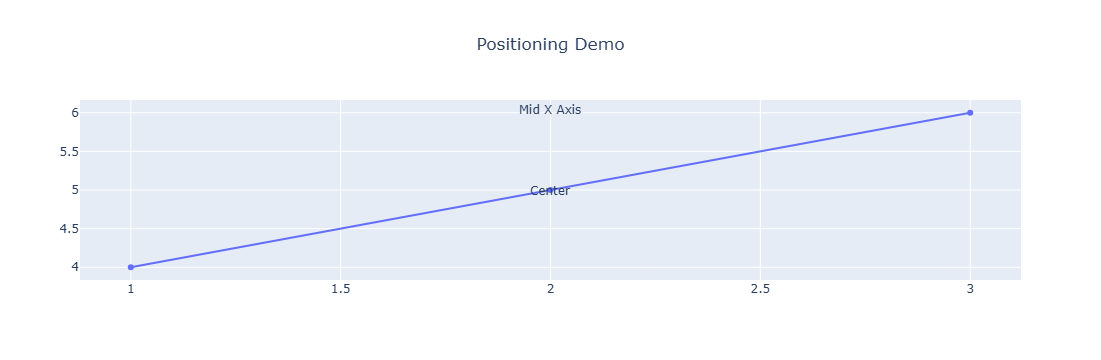

In [153]:
fig = go.Figure(data=go.Scatter(x=[1,2,3], y=[4,5,6]))

# Paper coordinate annotation
fig.add_annotation(
    text="Center",
    x=0.5, y=0.5,
    xref="paper", yref="paper",
    showarrow=False
)

# Axis domain annotation
fig.add_annotation(
    text="Mid X Axis",
    x=0.5, y=1,
    xref="x domain", yref="paper",
    showarrow=False
)

# Title (container-based)
fig.update_layout(
    title=dict(
        text="Positioning Demo",
        x=0.5
    )
)

fig.show()

# 📊 9. — 2D Cartesian Trace Types & Subplots

> ⚡ One-Line Summary

* 2D Cartesian subplots are the core plotting system in Plotly, where traces use xaxis and yaxis to decide where they are drawn, and multiple plots can be combined into powerful layouts.

>  🧠 1.  What is a 2D Cartesian Subplot?

* A 2D Cartesian subplot is the standard graph with:

1. X-axis (horizontal)
2. Y-axis (vertical)

* Almost all common charts (line, bar, scatter) use this system.
  
>  🎯 2.  How Traces Connect to Subplots

* Each trace tells Plotly which axes to use:



## 🧪 Example: Multiple Subplots

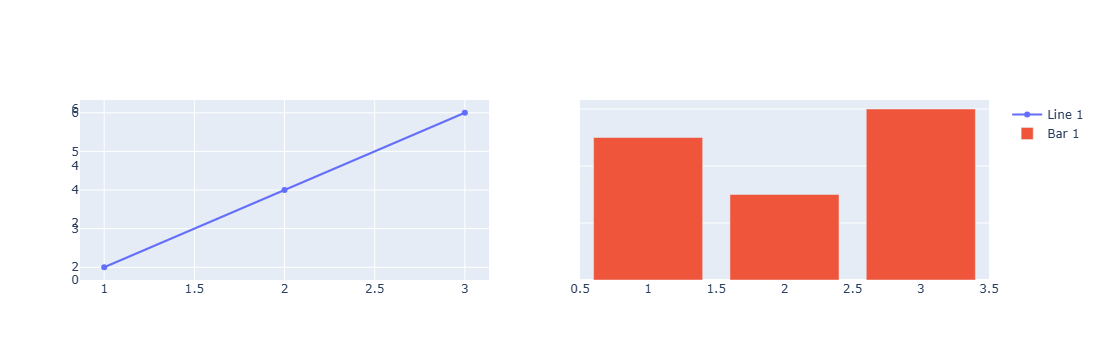

In [154]:
fig = go.Figure()

# First subplot (default)
fig.add_trace(go.Scatter(
    x=[1, 2, 3],
    y=[2, 4, 6],
    name="Line 1"
))

# Second subplot
fig.add_trace(go.Bar(
    x=[1, 2, 3],
    y=[5, 3, 6],
    xaxis="x2",
    yaxis="y2",
    name="Bar 1"
))

fig.update_layout(
    # First subplot
    xaxis=dict(domain=[0, 0.45]),
    yaxis=dict(domain=[0, 1]),

    # Second subplot
    xaxis2=dict(domain=[0.55, 1]),
    yaxis2=dict(domain=[0, 1])
)

fig.show()

### 🧠 3. Axis Types

### 🧪 Example: Different Axis Types

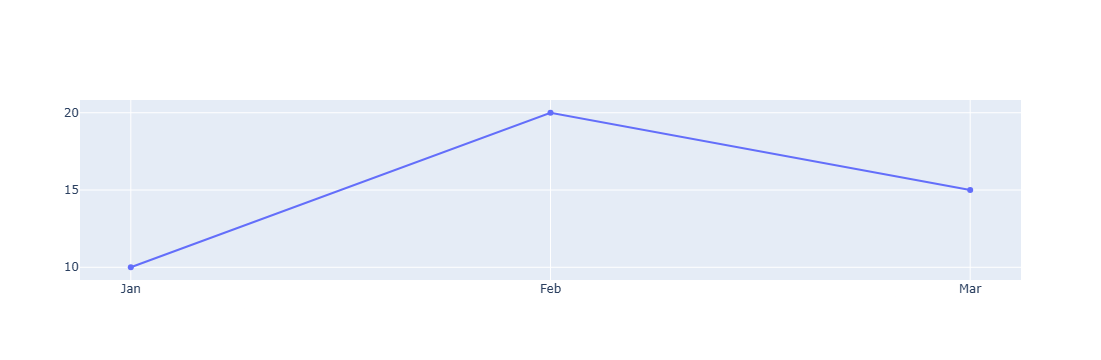

In [155]:
fig = go.Figure()
# single trace
fig.add_trace(go.Scatter(
    x=["Jan", "Feb", "Mar"],
    y=[10, 20, 15]
))

fig.update_layout(
    xaxis=dict(type="category"),
    yaxis=dict(type="linear")
)

fig.show()

### 🔄 4. Multiple Traces in One Subplot

>  You can combine different charts in the same axes:

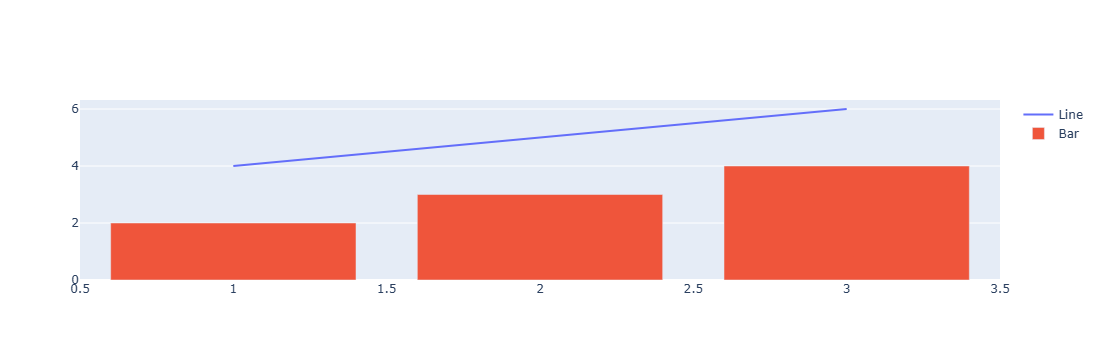

In [156]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[1, 2, 3],
    y=[4, 5, 6],
    mode='lines',
    name="Line"
))

fig.add_trace(go.Bar(
    x=[1, 2, 3],
    y=[2, 3, 4],
    name="Bar"
))

fig.show()

### 🔁 5. Dual Axis (Overlaying Axes)

>  Useful when data scales are different

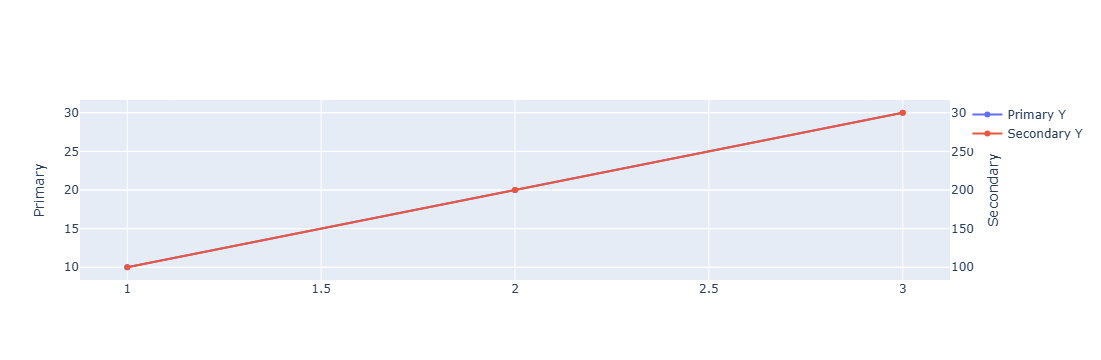

In [157]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[10,20,30],
    name="Primary Y"
))

fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[100,200,300],
    yaxis="y2",
    name="Secondary Y"
))

fig.update_layout(
    yaxis=dict(title="Primary"),
    yaxis2=dict(
        title="Secondary",
        overlaying="y",
        side="right"
    )
)

fig.show()

### 🧩 6. Small Multiples (Facets / Trellis)
> Multiple similar plots arranged in a grid

* 💡 Best created using:

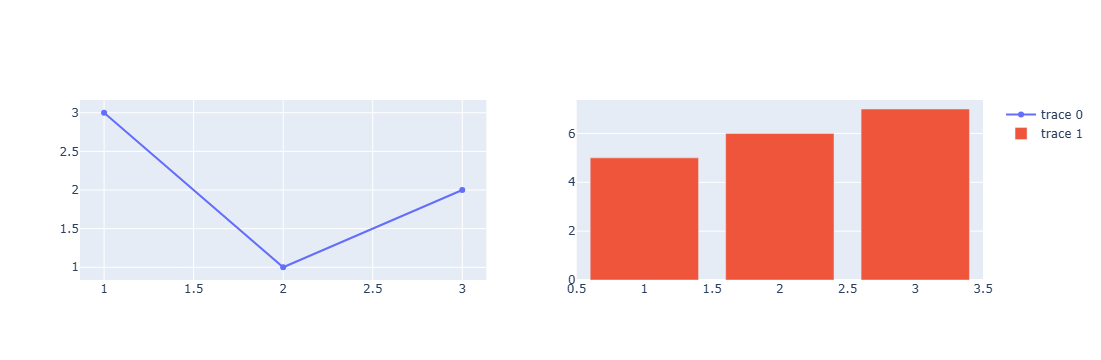

In [158]:
# from plotly.subplots import make_subplots

fig = make_subplots(rows= 1 , cols= 2)

fig.add_trace(go.Scatter(x=[1,2,3], y=[3,1,2]), row=1, col=1)
fig.add_trace(go.Bar(x=[1,2,3], y=[5,6,7]) , row=1, col=2)

fig.show()

### 📦 7. Important 2D Cartesian Trace Types

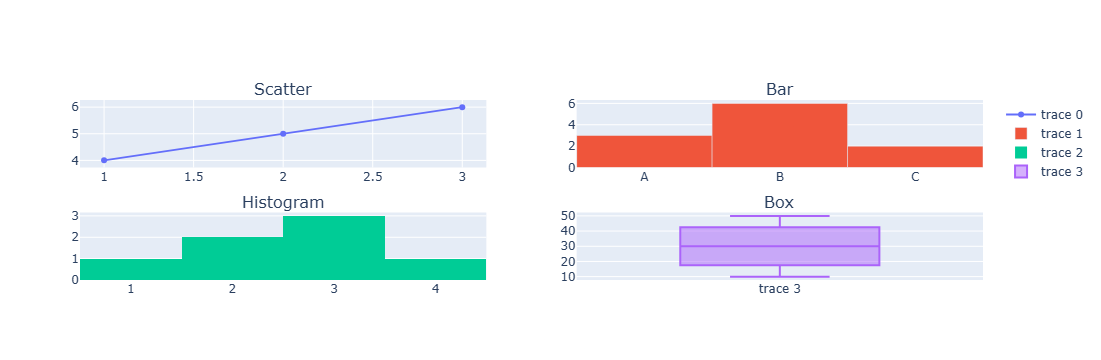

In [159]:
fig = make_subplots(rows=2 , cols= 2 , subplot_titles= ('Scatter' , 'Bar' , 'Histogram' , 'Box'))

# Scatter
fig.add_trace(go.Scatter(x=[1,2,3], y=[4,5,6]), row=1, col=1)

# Bar
fig.add_trace(go.Bar(x=["A","B","C"], y=[3,6,2]), row=1, col=2)

# Histogram
fig.add_trace(go.Histogram(x=[1,2,2,3,3,3,4]), row=2, col=1)

# Box
fig.add_trace(go.Box(y=[10,20,30,40,50]), row=2, col=2)

fig.show()

### 🚀 Key Takeaways
1. Every trace connects to a subplot using xaxis and yaxis
2. Subplots are controlled in layout
> You can:
1.  Combine multiple traces
2. Use multiple axes
3. Create grids (small multiples)
4. 2D Cartesian is the foundation of most Plotly charts
---

# 📘 10.  — 3D, Polar, Ternary & Smith Plots in Plotly

> ⚡ Core Idea

* Plotly supports non-2D subplot types, each with its own coordinate system:

1. trace.scene = "scene"
2. trace.polar = "polar"
3. trace.ternary = "ternary"
4. trace.smith = "smith"

> 🔷 1. 3D PLOTS (scene)
* 💡 Concept

 3D plots use scene instead of xaxis/yaxis.
 * ✅ Example: 3D Scatter

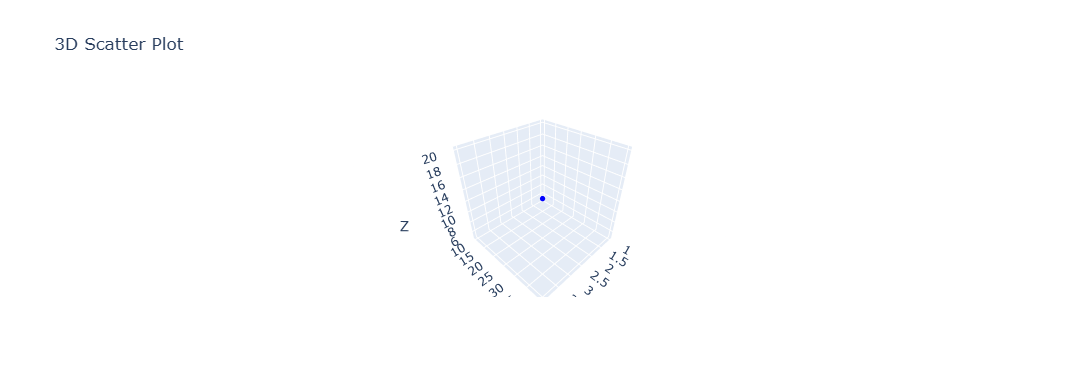

In [160]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(

    x=[1,2,3,4],
    y=[10,20,30,40],
    z=[5,10,15,20],
    mode = 'markers',
    marker= dict(size = 3 , color = 'blue'),
    scene  = 'scene'
))

fig.update_layout(
    title = ' 3D Scatter Plot',
    scene  = dict(
        xaxis_title = 'X',
        yaxis_title = 'Y',
        zaxis_title = 'Z',
        
    )
)
fig.show()

## 🔥 Advanced 3D Trace Types in Plotly

### 🔥 Other 3D Trace Types
1. Surface → terrain-like plots
2. Mesh3d → 3D shapes
3. Cone → vector fields
4. Volume → 3D density

### 🟩 1. Surface → Terrain / Heatmap in 3D

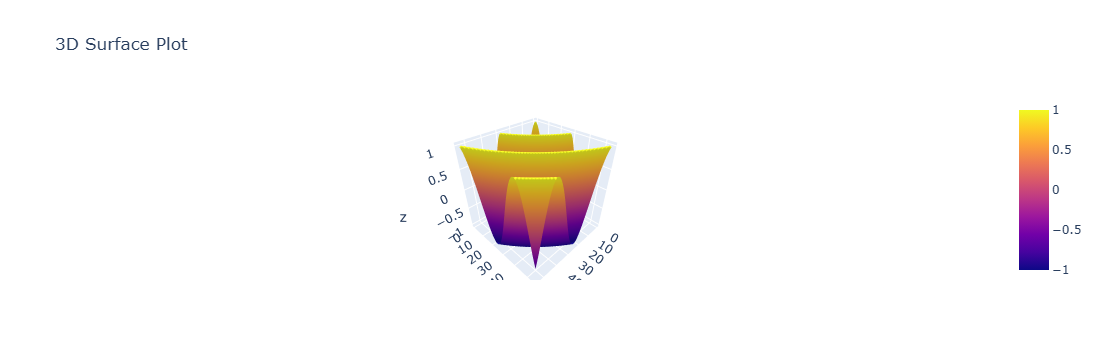

In [161]:
# import numpy as np

x = np.linspace(10 , 25 , 55 )
y = np.linspace(10 , 25 , 55 )

x , y = np.meshgrid(x, y) # np.meshgrid takes 1D arrays (x and y) and creates 2D grids (X, Y)
z = np.sin(np.sqrt(x**2 + y**2))  
# so you can represent all (x, y) coordinate pairs
fig = go.Figure(data = [
    go.Surface(z=z) # useful for evaluating functions like Z = f(x, y) and for 2D/3D plots
])

fig.update_layout(title = '3D Surface Plot')
fig.show()

### 🟦 2. Mesh3d → Custom 3D Shapes
> 💡 Concept
1. You define vertices + triangles
2. Used for irregular 3D objects
> ✅ Example: Pyramid

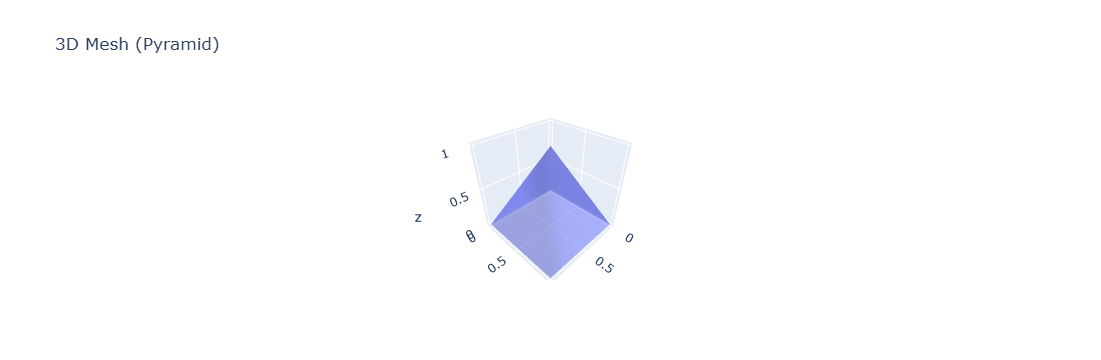

In [162]:
fig = go.Figure(data = [
    go.Mesh3d(
        x=[0,1,1,0,0.5],
        y=[0,0,1,1,0.5],
        z=[0,0,0,0,1],
        opacity = 0.5
    )
])
fig.update_layout(title="3D Mesh (Pyramid)")
fig.show()

### 🟨 3. Cone → Vector Fields
> 💡 Concept
1. Shows direction + magnitude
2. Each cone = a vector

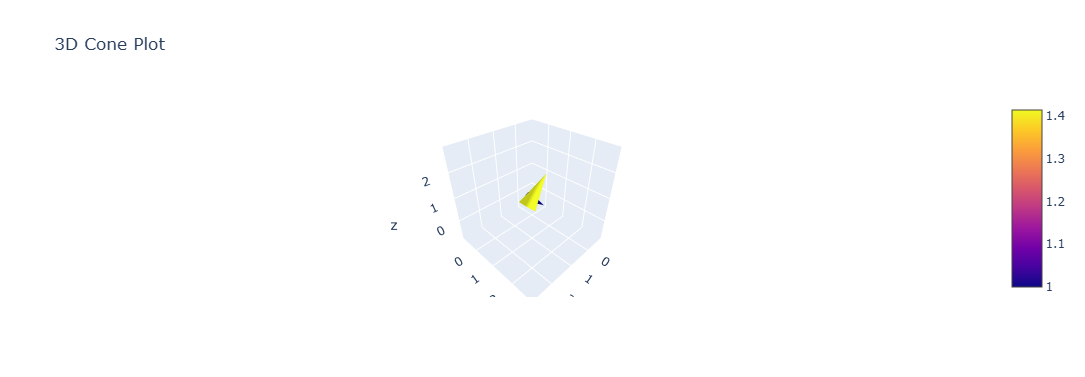

In [163]:
fig = go.Figure(data=[
    go.Cone(
        x=[0,1,2],
        y=[0,1,2],
        z=[0,1,2],
        u=[1,0,-1],
        v=[0,1,0],
        w=[0,0,1]
    )
])

fig.update_layout(title="3D Cone Plot")
fig.show()

###  🟪 4. Volume → 3D Density Visualization
> 💡 Concept
1. Works with 3D scalar fields
2. Shows density inside a volume

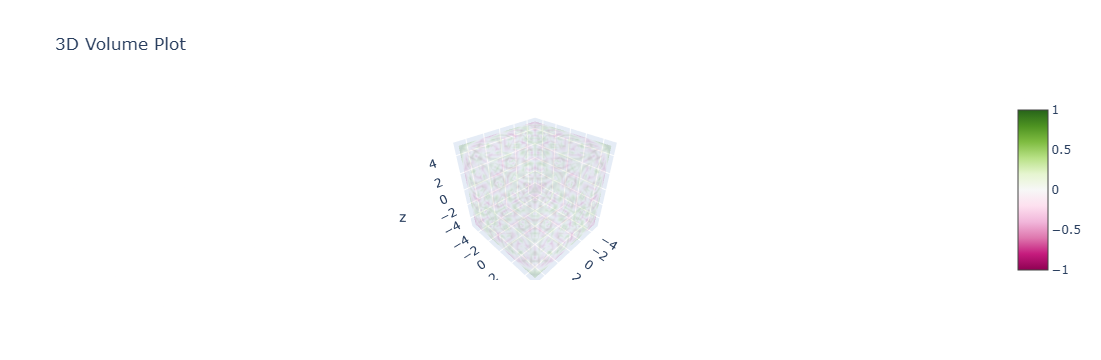

In [164]:
x, y, z = np.mgrid[-5:5:20j, -5:5:20j, -5:5:20j]
values = np.sin(x*y*z)

fig = go.Figure(data=go.Volume(
    x=x.flatten(),
    y=y.flatten(),
    z=z.flatten(),
    value=values.flatten(),
    opacity=0.1
))

fig.update_layout(title="3D Volume Plot")
fig.show()

## 🔴 2. POLAR PLOTS (polar)
> 💡 Concept

> Instead of (x, y) → use:

1. r → radius
2. theta → angle

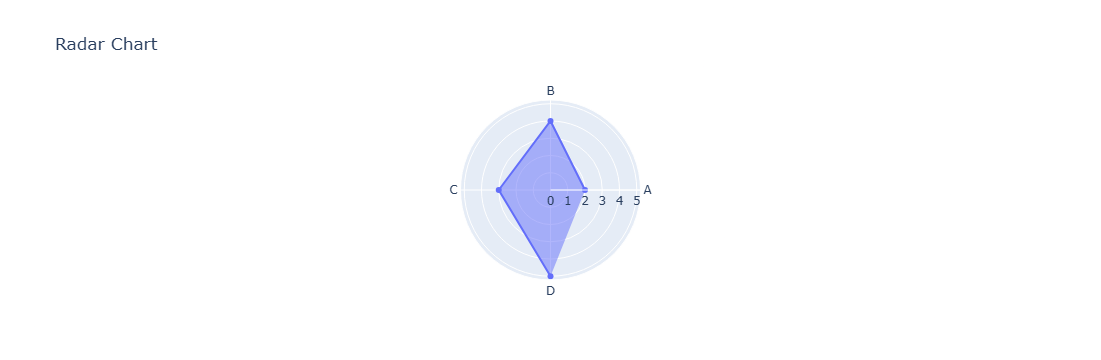

In [165]:
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=[2,4,3,5],
    theta=["A","B","C","D"],
    fill='toself',
    name="Performance",
    subplot="polar"   
))

fig.update_layout(
    title="Radar Chart",
    polar=dict(
        radialaxis=dict(visible=True)
    )
)

fig.show()

### 🟢 3. TERNARY PLOTS (ternary)
💡 Concept

Used when 3 variables sum to 100%

Coordinates:

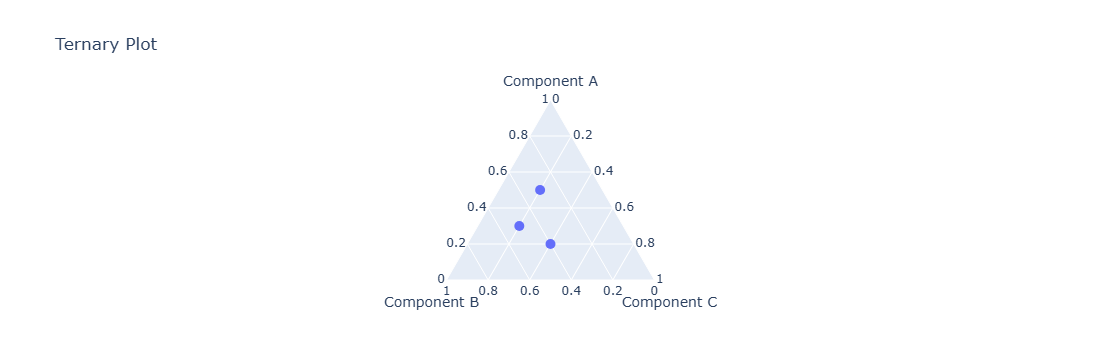

In [166]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatterternary(
    a=[30, 50, 20],
    b=[50, 30, 40],
    c=[20, 20, 40],
    mode='markers',
    marker=dict(size=10)
))

fig.update_layout(
    title="Ternary Plot"
)

fig.show()

## 🚀 Mental Model (This matters a lot)
1. Surface → “height map”
2. Mesh3d → “build your own object”
3. Cone → “arrows in space”
4. Volume → “see inside space”
### ⚡ One-Line Summary

*  These 3D traces let you visualize shape (Mesh), surface (Surface), direction (Cone), and density (Volume) — covering almost every real-world 3D scenario.
---

# 🌍 11. Map Trace Types and Subplots (Plotly)

> ⚡ Core Idea

* Plotly supports two different map systems:

## 1️⃣ Geo Subplots (Outline Maps)
1. Built-in world/country maps (no external tiles)
2. Lightweight
3. Good for simple geographic visualization

>  Uses:

1. scattergeo
2. choropleth

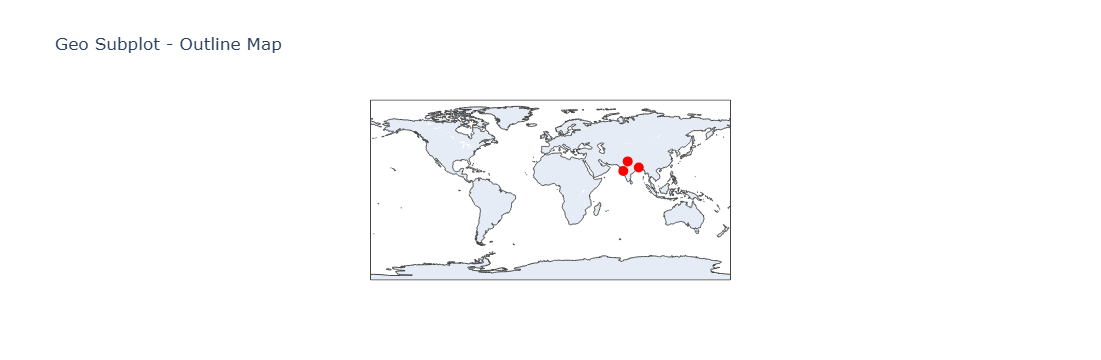

In [167]:
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    lon=[77.2, 72.8, 88.3],
    lat=[28.6, 19.0, 22.5],
    mode='markers',
    marker=dict(size=10, color='red'),
    text=["Delhi", "Mumbai", "Kolkata"]
))

fig.update_layout(
    title="Geo Subplot - Outline Map",
    geo=dict(
        showland=True
    )
)

fig.show()

## 2️⃣ Tile Maps (Mapbox-based Maps)
1. Real maps with zoom, streets, satellite, etc.
2. Interactive like Google Maps

>  Uses:

1. scattermap
2. choroplethmap
3. densitymap

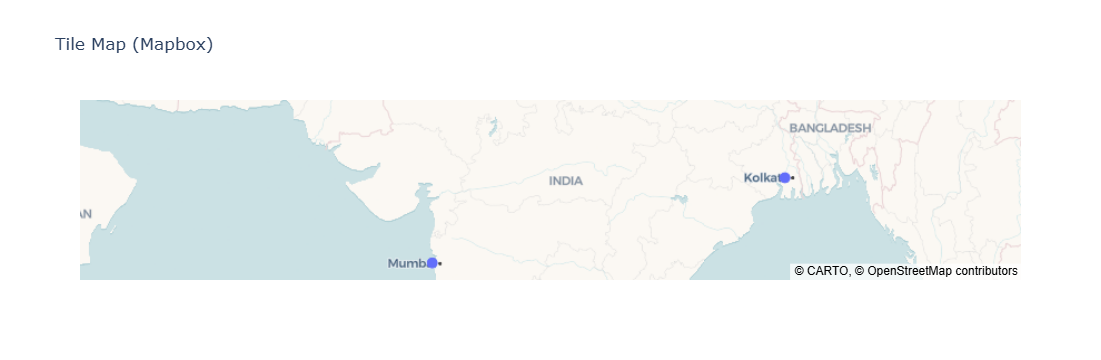

In [168]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scattermap(
    lon=[77.2, 72.8, 88.3],
    lat=[28.6, 19.0, 22.5],
    mode='markers',
    marker=dict(size=12),
    text=["Delhi", "Mumbai", "Kolkata"]
))

fig.update_layout(
    title="Tile Map (Mapbox)",
    map=dict(
        center=dict(lat=22, lon=78),
        zoom=4
    )
)

fig.show()

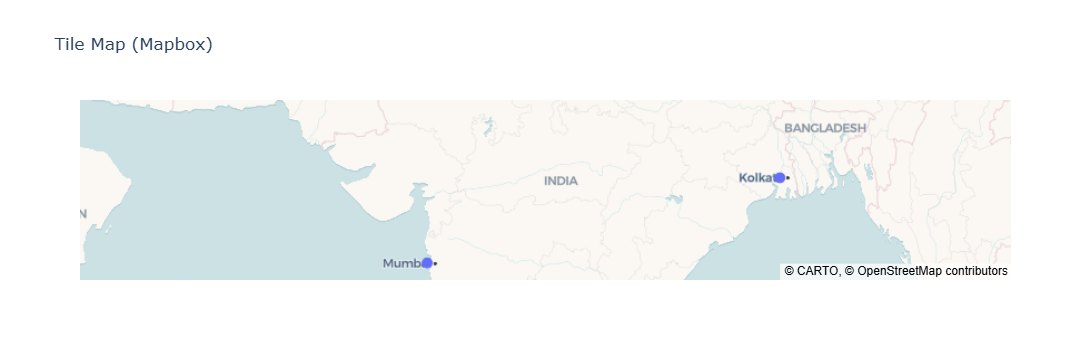

In [169]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scattermap(
    lon=[77.2, 72.8, 88.3],
    lat=[28.6, 19.0, 22.5],
    mode='markers',
    marker=dict(size=12),
    text=["Delhi", "Mumbai", "Kolkata"]
))

fig.update_layout(
    title="Tile Map (Mapbox)",
    map=dict(
        center=dict(lat=22, lon=78),
        zoom=4
    )
)

fig.show()

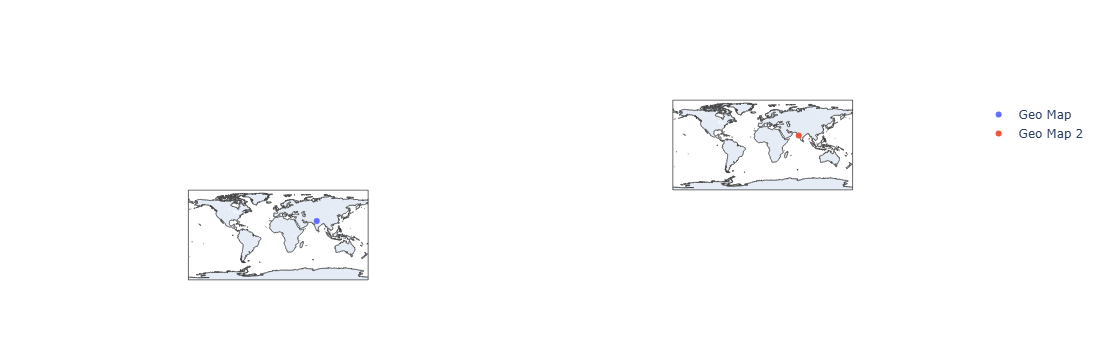

In [170]:
# Multiple Map Subplots

fig = go.Figure()

# First geo map
fig.add_trace(go.Scattergeo(
    lon=[77], lat=[28],
    geo="geo",
    name="Geo Map"
))

# Second geo map
fig.add_trace(go.Scattergeo(
    lon=[72], lat=[19],
    geo="geo2",
    name="Geo Map 2"
))

fig.update_layout(
    geo=dict(domain=dict(x=[0, 0.45])),
    geo2=dict(domain=dict(x=[0.55, 1]))
)

fig.show()

# 🧩 12. Traces Which Are Their Own Subplots
> ⚡ Core Idea

* Some Plotly traces do NOT use x/y axes, geo, or map.

> 👉 Instead:

1. They are independent visual blocks
2. Each trace is basically its own mini-plot
3. Positioned using domain (paper coordinates)

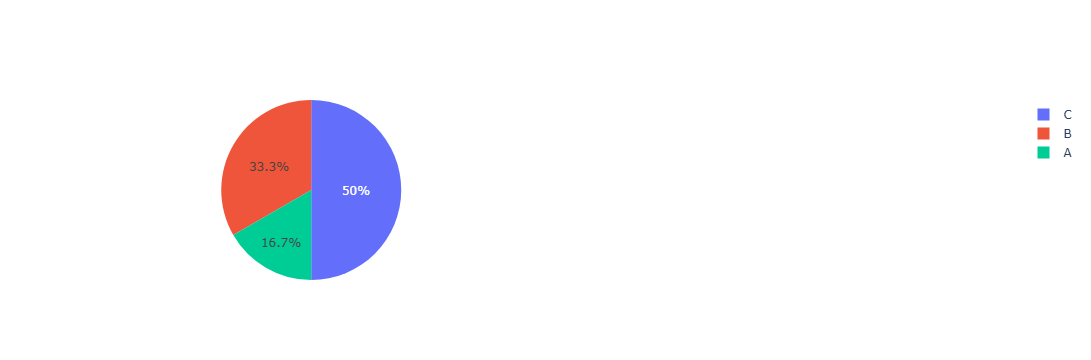

In [178]:
fig = go.Figure()

fig.add_trace(go.Pie(
    labels=["A", "B", "C"],
    values=[10, 20, 30],
    domain=dict(x=[0, 0.5])
))

fig.show()

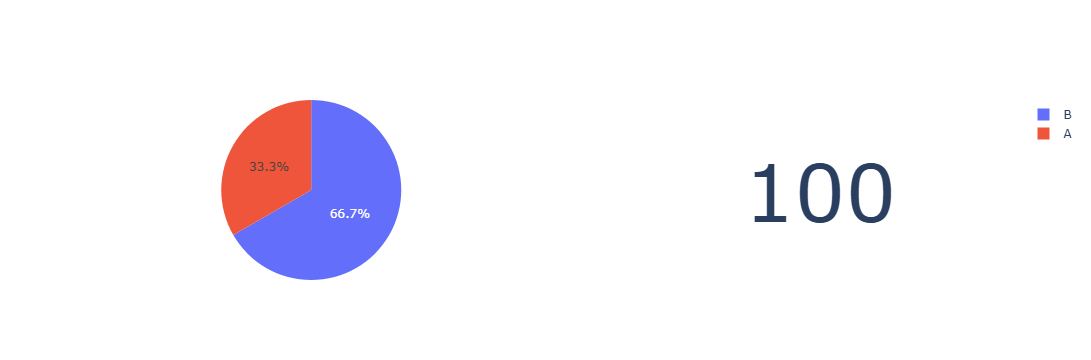

In [172]:
fig = go.Figure()

# Pie (left)
fig.add_trace(go.Pie(
    labels=["A","B"],
    values=[10,20],
    domain=dict(x=[0, 0.5])
))

# Indicator (right)
fig.add_trace(go.Indicator(
    mode="number",
    value=100,
    domain=dict(x=[0.6, 1])
))

fig.show()

#  🧶 13. Carpet Trace Types and Subplots
> ⚡ Core Idea

* A carpet plot is a custom coordinate system.

> 👉 Instead of normal (x, y) axes:

1. You define two axes: a and b
2. These can be curved, skewed, or irregular

> Then:

1. Other traces attach to this carpet
2. Using the carpet attribute

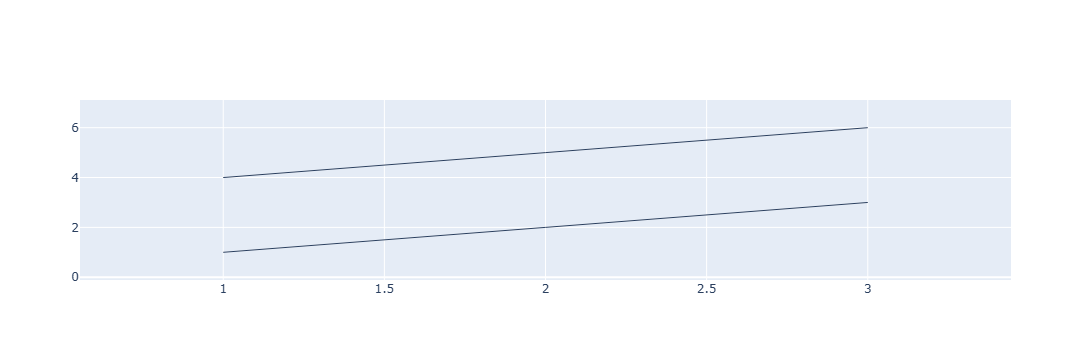

In [173]:
fig = go.Figure()

# Carpet base
fig.add_trace(go.Carpet(
    a=[1,2,3,1,2,3],
    b=[1,1,1,2,2,2],
    x=[1,2,3,1,2,3],
    y=[1,2,3,4,5,6],
    carpet="carpet1"
))

# Points on carpet
fig.add_trace(go.Scattercarpet(
    a=[1.5, 2.5],
    b=[1.5, 1.2],
    mode='markers',
    marker=dict(size=10, color='red'),
    carpet="carpet1"
))

fig.show()

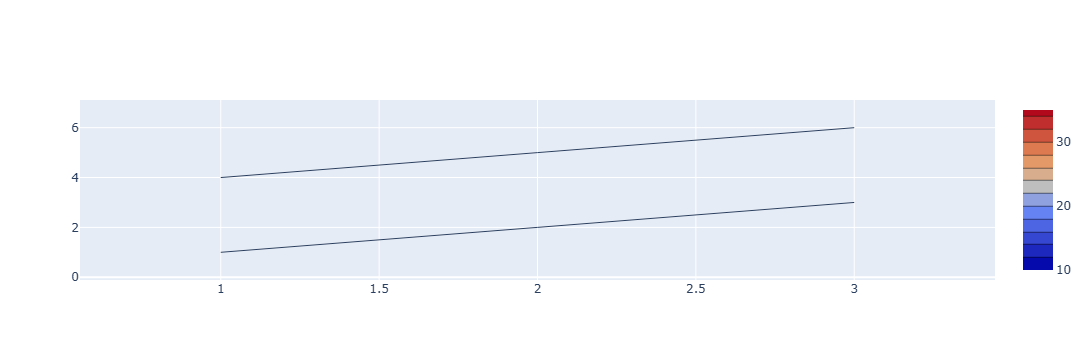

In [174]:
fig = go.Figure()

fig.add_trace(go.Carpet(
    a=[1,2,3,1,2,3],
    b=[1,1,1,2,2,2],
    x=[1,2,3,1,2,3],
    y=[1,2,3,4,5,6],
    carpet="carpet1"
))

fig.add_trace(go.Contourcarpet(
    z=[10, 20, 30, 15, 25, 35],
    carpet="carpet1"
))

fig.show()

In [175]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[2,4,6],
    name="Line A"
))

fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[3,5,7],
    name="Line B"
))

fig.show()

# 🎨 14. Trace Types, Legends and Color Bars
> ⚡ Core Idea

* There are two parallel systems in Plotly:

>  1️⃣ Legends (for discrete data)
1. Show/hide traces
2. Represent categories
   
>  2️⃣ Color Bars (for continuous data)
1. Represent numeric scale
2. Like a gradient legend

In [176]:
fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[2,4,6],
    name="Line A"
))

fig.add_trace(go.Scatter(
    x=[1,2,3],
    y=[3,5,7],
    name="Line B"
))

fig.show()

# 🚀 15. What About Dash?

## ⚡ Core Idea

> Dash is a Python framework that lets you turn your Plotly figures into interactive web apps — without writing JavaScript.

1. Plotly → Visualizations
2. Dash   → Full Applications (UI + Interaction)

In [177]:
# Create app
app = Dash(__name__)

# Create figure
fig = go.Figure(data=go.Scatter(
    x=[1,2,3],
    y=[4,1,2]
))

# Layout
app.layout = html.Div([
    html.H1("My First Dash App"),
    dcc.Graph(figure=fig)
])

# Run app
if __name__ == "__main__":
    app.run(debug=True)